<a href="https://colab.research.google.com/github/16ajoop/Machine-Learning/blob/main/LNNwith_2_dense_layer(no_activation_fn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
TRAIN_DIR ="/content/drive/MyDrive/cats-dogs-classification/train"
TEST_DIR = "/content/drive/MyDrive/cats-dogs-classification/test"

In [4]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import math

In [31]:
# CONFIG
IMG_HEIGHT, IMG_WIDTH = 150, 150
IMG_CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 20

In [32]:
# LOAD data
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.1, subset="training",
    seed=123, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.1, subset="validation",
    seed=123, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, shuffle=False
)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

Found 1120 files belonging to 2 classes.
Using 1008 files for training.
Found 1120 files belonging to 2 classes.
Using 112 files for validation.
Found 280 files belonging to 2 classes.
Classes: ['cats', 'dogs']


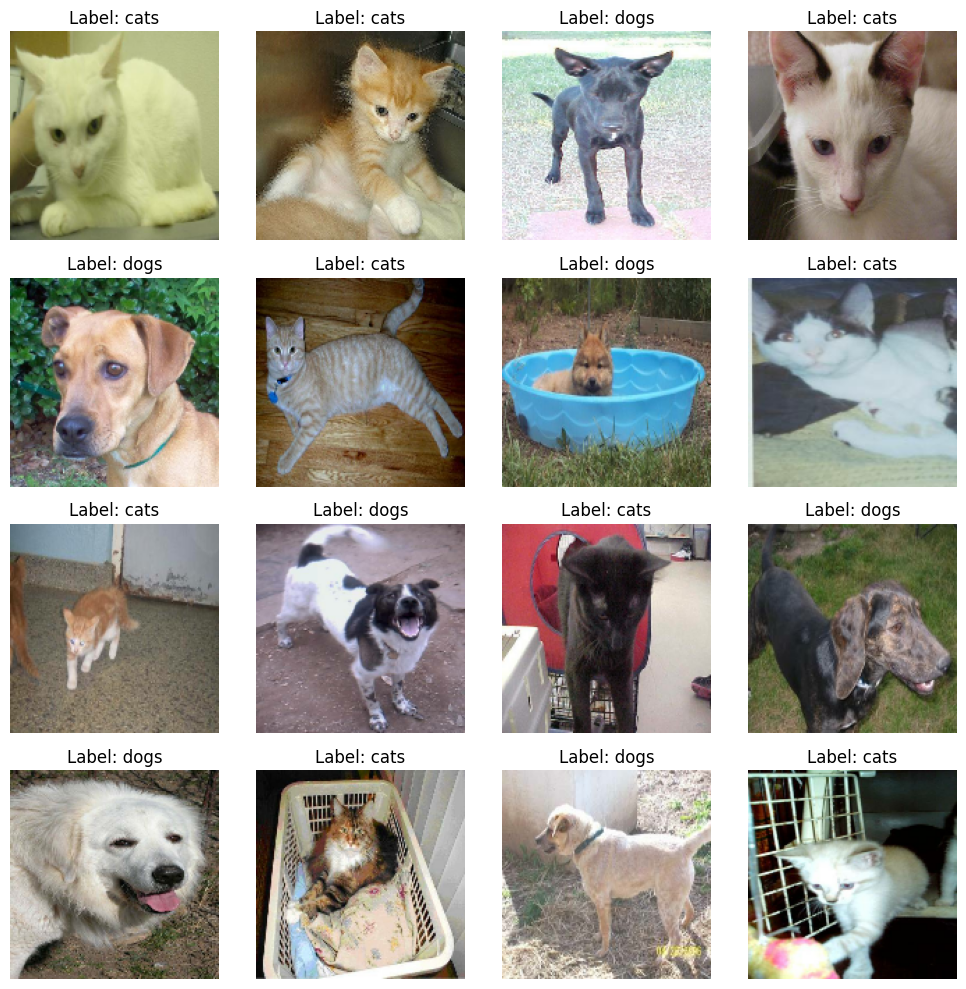

In [33]:
# peek att the batch of images before caching/prefetch changes anything
for image_batch, label_batch in train_ds.take(1):
  fig, axes = plt.subplots(4, 4, figsize=(10, 10))
  for i in range(16):
    ax = axes[i // 4, i % 4]
    ax.imshow(image_batch[i].numpy().astype("uint8"))
    ax.set_title(f"Label: {CLASS_NAMES[label_batch[i]]}")
    ax.axis("off")
  plt.tight_layout()
  plt.show()

In [34]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [49]:
# MODEL:  FLATTEN ---> DENSE(128, no activation) ---> DENSE(output)
linear_model = keras.Sequential([
    keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Rescaling(1./255),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

In [50]:
linear_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # 10x smaller than default
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

linear_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 67500)          │       270,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │     2,160,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,098 (9.27 MB)

 Trainable params: 2,295,098 (8.76 MB)

 Non-trainable params: 135,000 (527.34 KB)

In [51]:
#  TRAIN
history = linear_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.5367 - loss: 1.9302 - val_accuracy: 0.3839 - val_loss: 1.4313
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6766 - loss: 1.3742 - val_accuracy: 0.5000 - val_loss: 1.0423
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7877 - loss: 0.7023 - val_accuracy: 0.5804 - val_loss: 0.8468
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8651 - loss: 0.3916 - val_accuracy: 0.5893 - val_loss: 0.9640
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9167 - loss: 0.2103 - val_accuracy: 0.6071 - val_loss: 0.8778
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9365 - loss: 0.1758 - val_accuracy: 0.5893 - val_loss: 1.1107
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9563 - loss: 0.1187 - val_accuracy: 0.5982 - val_loss: 1.1047
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0699 - val_accuracy: 0.5268 - val_loss

In [52]:
# EVALUATE
test_loss, test_acc = linear_model.evaluate(test_ds)
print(f"Linear model test accuracy: {test_acc:.4f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6071 - loss: 1.6465
Linear model test accuracy: 0.6071


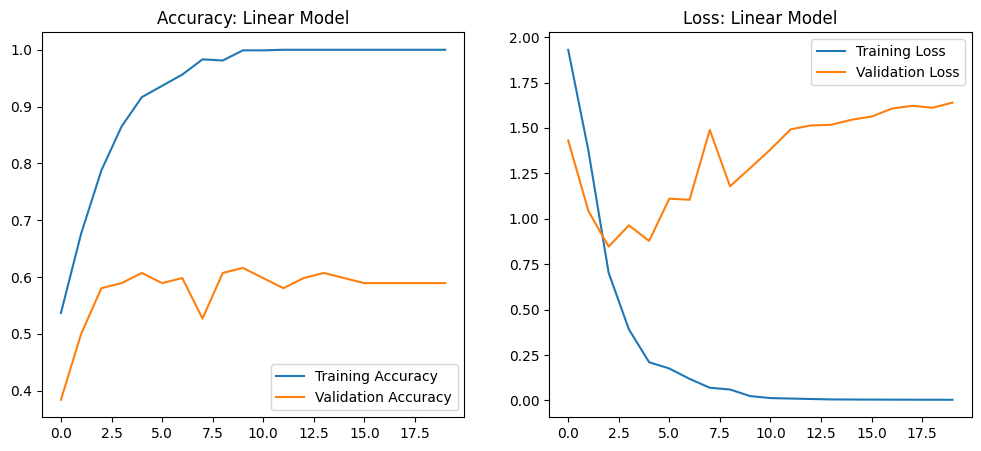

[1.93024742603302, 1.374192714691162, 0.7022827863693237, 0.3915711045265198, 0.210298553109169, 0.175750270485878, 0.11871514469385147, 0.0699046179652214, 0.060159631073474884, 0.023845933377742767, 0.01301726046949625, 0.010335286147892475, 0.007952146232128143, 0.005561793688684702, 0.005033360794186592, 0.004608857911080122, 0.004291533958166838, 0.004070648457854986, 0.003819298231974244, 0.0036171958781778812]
[1.4312775135040283, 1.0423182249069214, 0.8467751145362854, 0.9639517664909363, 0.8778104782104492, 1.110744595527649, 1.1046816110610962, 1.488845705986023, 1.1788408756256104, 1.2793689966201782, 1.3818988800048828, 1.492296814918518, 1.5137988328933716, 1.517264723777771, 1.5448542833328247, 1.5625618696212769, 1.6065374612808228, 1.6217416524887085, 1.6112240552902222, 1.6393039226531982]


In [53]:
# Plot training curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy: Linear Model')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss: Linear Model')

plt.show()

print(loss)
print(val_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


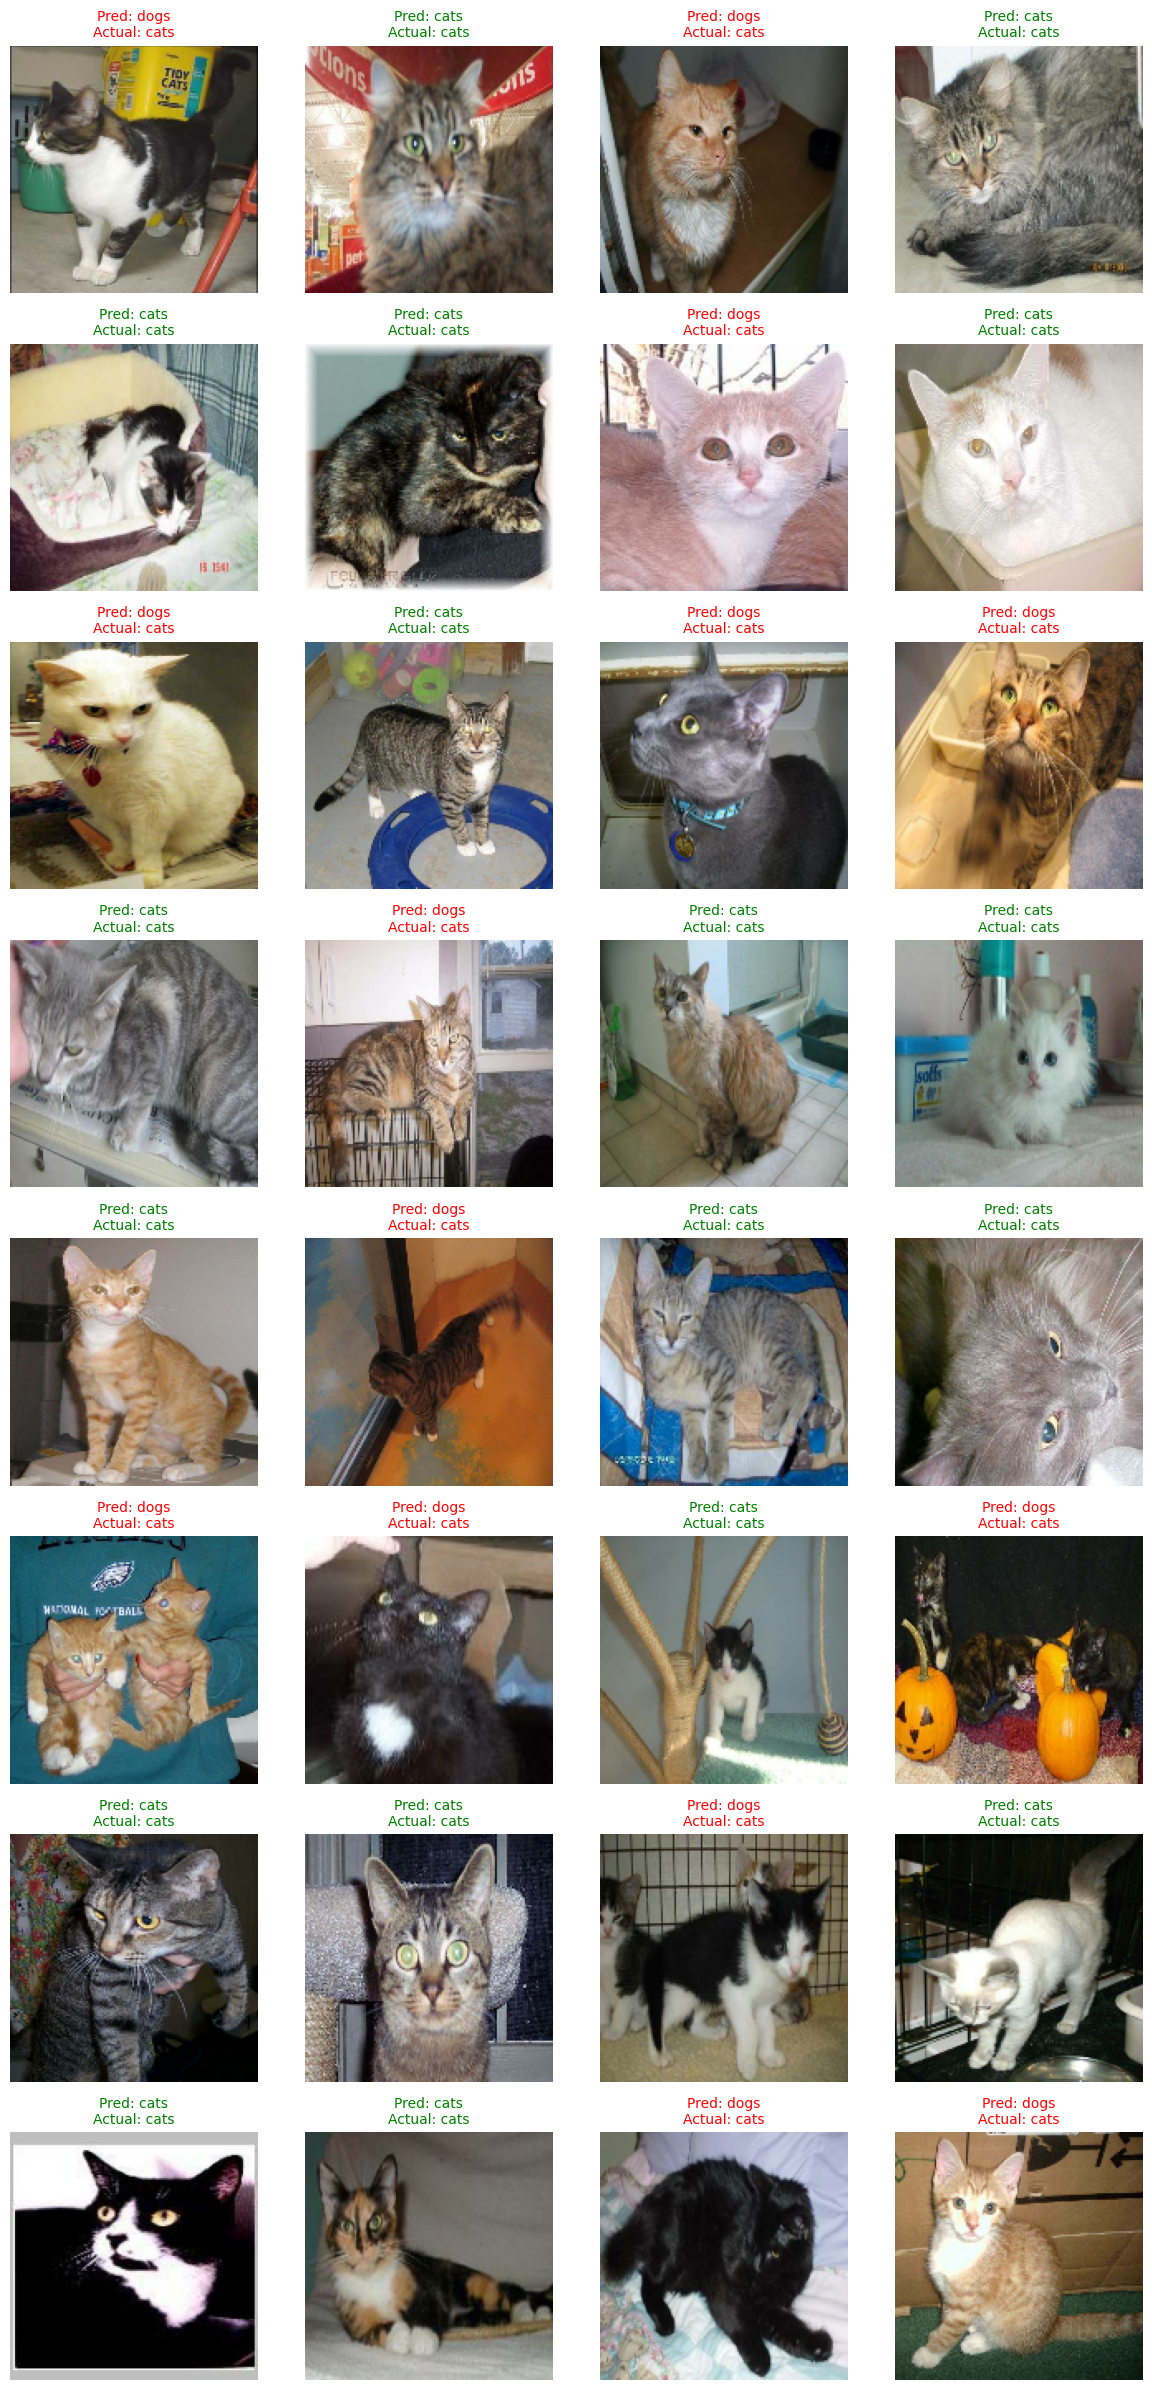

In [54]:
# Predictions vs actual labels on a test batch
for images, labels in test_ds.take(1):
  batch_predictions = linear_model.predict(images)
  predicted_indices = np.argmax(batch_predictions, axis=1)

  num_images = images.shape[0]
  num_cols = 4
  num_rows = math.ceil(num_images / num_cols)

  plt.figure(figsize=(12, 3 * num_rows))

  for i in range(num_images):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis('off')

    pred_class = CLASS_NAMES[predicted_indices[i]]
    actual_class = CLASS_NAMES[labels[i].numpy()]

    color = "green" if pred_class == actual_class else "red"
    plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10, color=color)

  plt.tight_layout()
  plt.show()